# Run and Plot a Retrieval

This notebook demonstrates how to run a trained retrieval model on real microwave radiometer measurements and plot the results.

In [31]:
DATA_DIR = 'data'\n
%config InlineBackend.figure_format = 'svg'

from datetime import datetime

from openMWR.utils import setup_logging
logger = setup_logging()

In [32]:
site = 'munich_G5'

date = datetime(2025,1,12)

## Run the Retrieval

The first step is to load the trained model for the specified site.

In [33]:
from openMWR.models import Model
model = Model.load('NN_opt', site, DATA_DIR)

Then, the measurement data for the site and date is imported. The keyword import_retrieval_data can be set to True to import the retrieval data of an RPG retrieval, if available.

In [34]:
from openMWR.hatpro_data import import_hatpro_data
ds_hatpro = import_hatpro_data(date, 
                               site, 
                               import_retrieval_data=False, 
                               mean_one_min=True)
ds_hatpro

<xarray.Dataset> Size: 178kB
Dimensions:           (time: 1344, frq: 14)
Coordinates:
  * time              (time) datetime64[ns] 11kB 2025-01-12 ... 2025-01-12T23...
  * frq               (frq) float64 112B 22.24 23.04 23.84 ... 56.66 57.3 58.0
Data variables:
    TB                (time, frq) float32 75kB 19.04 19.61 17.85 ... 268.2 268.6
    rain_flag         (time) float64 11kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    azimuth_angle     (time) float32 5kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    elevation_angle   (time) float32 5kB 90.0 90.0 90.0 90.0 ... 90.0 90.0 90.0
    TB_IR             (time) float32 5kB 259.5 259.1 258.8 ... 261.0 260.2 261.1
    surface_p         (time) float64 11kB 965.0 965.0 965.0 ... 973.9 973.9
    surface_T         (time) float64 11kB 271.0 270.9 270.9 ... 271.1 271.1
    surface_rh        (time) float64 11kB 76.2 75.87 76.0 ... 73.08 73.24 73.33
    doy_cos           (time) float64 11kB 0.9292 0.9292 0.9292 ... 0.9292 0.9292
    doy_sin           (time) float64 11kB 0.3695 0.3695 0.3695 ... 0.3695 0.3695
    years_since_1970  (time) float64 11kB 55.03 55.03 55.03 ... 55.03 55.03
Attributes:
    netCDF_Convention:             CF-1.0
    Radiometer_Location:           University of Madison
    Radiometer_System:             RPG-HATPRO
    Serial_Number:                 R-DPR-19/007
    Station_Altitude:              200
    Station_Longitude:             85�43'55'' West
    Station_Latitude:              43�22'42'' North
    Comment:                       
    Radiometer_Software_Version:  V10.00
    Host-PC_Software_Version:     V10.00

The openMWR.run.run_model function can be used to run the retrieval.

In [35]:
from openMWR.run import run_model
device='cpu'
pred = run_model(model, ds_hatpro, device)
pred

<xarray.Dataset> Size: 6MB
Dimensions:     (time: 1344, frq: 14, height: 208)
Coordinates:
  * time        (time) datetime64[ns] 11kB 2025-01-12 ... 2025-01-12T23:59:00
  * frq         (frq) float64 112B 22.24 23.04 23.84 25.44 ... 56.66 57.3 58.0
  * height      (height) int64 2kB 0 10 25 50 75 ... 28500 29000 29500 30000
Data variables:
    TB          (time, frq) float32 75kB 19.04 19.61 17.85 ... 267.7 268.2 268.6
    TB_IR       (time) float32 5kB 259.5 259.1 258.8 259.2 ... 261.0 260.2 261.1
    surface_T   (time) float64 11kB 271.0 270.9 270.9 ... 271.2 271.1 271.1
    surface_p   (time) float64 11kB 965.0 965.0 965.0 ... 973.9 973.9 973.9
    surface_rh  (time) float64 11kB 76.2 75.87 76.0 75.9 ... 73.08 73.24 73.33
    doy_cos     (time) float64 11kB 0.9292 0.9292 0.9292 ... 0.9292 0.9292
    doy_sin     (time) float64 11kB 0.3695 0.3695 0.3695 ... 0.3695 0.3695
    T           (height, time) float64 2MB 271.5 271.6 271.4 ... 218.4 218.4
    rh          (height, time) float64 2MB 75.83 75.47 75.68 ... 1.296 1.303
    lwc         (height, time) float32 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    lwp         (time) float32 5kB 79.95 60.46 58.25 64.58 ... 29.99 27.72 30.73
    iwv         (time) float64 11kB 6.172 6.112 6.149 ... 3.364 3.309 3.354
Attributes:
    netCDF_Convention:             CF-1.0
    Radiometer_Location:           University of Madison
    Radiometer_System:             RPG-HATPRO
    Serial_Number:                 R-DPR-19/007
    Station_Altitude:              200
    Station_Longitude:             85�43'55'' West
    Station_Latitude:              43�22'42'' North
    Comment:                       
    Radiometer_Software_Version:  V10.00
    Host-PC_Software_Version:     V10.00

To plot the results in a SkewT diagram later, some derived quantities, such as the dew point, must first be calculated. This can be done using the calc_derived_quantities function from openMWR.hatpro_data.

In [36]:
from openMWR.hatpro_data import calc_derived_quantities
pred = calc_derived_quantities(pred)
pred

<xarray.Dataset> Size: 15MB
Dimensions:       (frq: 14, time: 1344, height: 208)
Coordinates:
  * frq           (frq) float64 112B 22.24 23.04 23.84 25.44 ... 56.66 57.3 58.0
  * time          (time) datetime64[ns] 11kB 2025-01-12 ... 2025-01-12T23:59:00
  * height        (height) int64 2kB 0 10 25 50 75 ... 28500 29000 29500 30000
Data variables: (12/18)
    TB            (time, frq) float32 75kB 19.04 19.61 17.85 ... 268.2 268.6
    TB_IR         (time) float32 5kB 259.5 259.1 258.8 ... 261.0 260.2 261.1
    surface_T     (time) float64 11kB 271.0 270.9 270.9 ... 271.2 271.1 271.1
    surface_p     (time) float64 11kB 965.0 965.0 965.0 ... 973.9 973.9 973.9
    surface_rh    (time) float64 11kB 76.2 75.87 76.0 75.9 ... 73.08 73.24 73.33
    doy_cos       (time) float64 11kB 0.9292 0.9292 0.9292 ... 0.9292 0.9292
    ...            ...
    ah            (height, time) float64 2MB 3.274 3.275 ... 0.0004688 0.0004712
    TD            (height, time) float64 2MB 267.8 267.8 267.7 ... 188.2 188.2
    T_grad        (height, time) float64 2MB -34.94 -30.44 -31.5 ... nan nan nan
    p             (time, height) float64 2MB 965.0 963.8 962.0 ... 10.34 9.563
    lwp_from_lwc  (time) float64 11kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    iwv_from_ah   (time) float64 11kB 6.317 6.338 6.371 ... 3.396 3.339 3.381
Attributes:
    netCDF_Convention:             CF-1.0
    Radiometer_Location:           University of Madison
    Radiometer_System:             RPG-HATPRO
    Serial_Number:                 R-DPR-19/007
    Station_Altitude:              200
    Station_Longitude:             85�43'55'' West
    Station_Latitude:              43�22'42'' North
    Comment:                       
    Radiometer_Software_Version:  V10.00
    Host-PC_Software_Version:     V10.00

There is also a convenient function available to import the data, run the retrieval and calculate derived quantities in one step: openMWR.run.import_data_and_run_retrieval. It can be used with a list of models to run multiple retrievals at once.

In [37]:
from openMWR.run import import_data_and_run_retrieval

pred, ds_hatpro= import_data_and_run_retrieval(date, 
                                               site, 
                                               'data', 
                                               [model], 
                                               import_retrieval_data=False, 
                                               smooth=False)
pred = pred.isel(model=0)
pred

2026-01-13 16:00:35,848 [openMWR.run] INFO: Using cpu device
2026-01-13 16:00:35,848 [openMWR.run] INFO: Using cpu device
2026-01-13 16:00:35,848 [openMWR.run] INFO: Using cpu device


<xarray.Dataset> Size: 15MB
Dimensions:       (frq: 14, time: 1344, height: 208)
Coordinates:
  * frq           (frq) float64 112B 22.24 23.04 23.84 25.44 ... 56.66 57.3 58.0
  * time          (time) datetime64[ns] 11kB 2025-01-12 ... 2025-01-12T23:59:00
  * height        (height) int64 2kB 0 10 25 50 75 ... 28500 29000 29500 30000
    model         <U6 24B 'NN_opt'
Data variables: (12/19)
    TB            (time, frq) float32 75kB 19.04 19.61 17.85 ... 268.2 268.6
    TB_IR         (time) float32 5kB 259.5 259.1 258.8 ... 261.0 260.2 261.1
    surface_T     (time) float64 11kB 271.0 270.9 270.9 ... 271.2 271.1 271.1
    surface_p     (time) float64 11kB 965.0 965.0 965.0 ... 973.9 973.9 973.9
    surface_rh    (time) float64 11kB 76.2 75.87 76.0 75.9 ... 73.08 73.24 73.33
    doy_cos       (time) float64 11kB 0.9292 0.9292 0.9292 ... 0.9292 0.9292
    ...            ...
    TD            (height, time) float64 2MB 267.8 267.8 267.7 ... 188.2 188.2
    T_grad        (height, time) float64 2MB -34.94 -30.44 -31.5 ... nan nan nan
    p             (time, height) float64 2MB 965.0 963.8 962.0 ... 10.34 9.563
    lwp_from_lwc  (time) float64 11kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    iwv_from_ah   (time) float64 11kB 6.317 6.338 6.371 ... 3.396 3.339 3.381
    rain_flag     (time) float64 11kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    netCDF_Convention:             CF-1.0
    Radiometer_Location:           University of Madison
    Radiometer_System:             RPG-HATPRO
    Serial_Number:                 R-DPR-19/007
    Station_Altitude:              200
    Station_Longitude:             85�43'55'' West
    Station_Latitude:              43�22'42'' North
    Comment:                       
    Radiometer_Software_Version:  V10.00
    Host-PC_Software_Version:     V10.00

## Plot the results

The SkewT object from openMWR.plot can be used to plot the results for a specific date and time. It is a flexible wrapper around the MetPy SkewT plotting functionality. It can be used to compare retrieval results to radiosonde measurements and other retrievals. The plot_radiosonde method plots the closest radiosonde to the specified time that can be found in the 'data/radiosondes/station_id' directory.

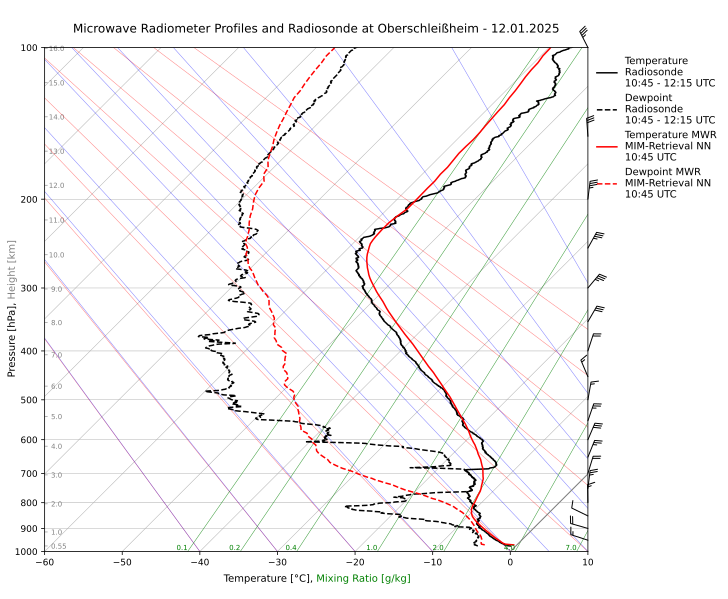

In [38]:
from openMWR.plot import SkewT
from openMWR.site import get_config_parameter

raso_station_id = '03715'

station_alt = get_config_parameter(site, 'mwr_height')

noon = date.replace(hour=12)

skew = SkewT(noon, DATA_DIR, station_alt=station_alt)
skew.plot_radiosonde(raso_station_id)
skew.plot_retrieval(pred, 'MIM-Retrieval NN', color='red')
skew.finalize()

To plot data from a full day, the TimeSeriesPlot object from openMWR.plot can be used. It is a wrapper around Matplotlib.

In [39]:
from openMWR.plot import TimeSeriesPlot

pre_title = 'Meteorological Institute of Ludwig-Maximilians-Universität (München, Germany; 48.148 N / 11.573 E)'
pred['rain_flag'] = ds_hatpro['rain_flag'].sel(time=pred.time)
data = pred.sel(height=slice(0, 10000)).transpose('time', ...)

temp = TimeSeriesPlot(date, 
                      'Temperature - Hatpro Retrieval (NN)', 
                      pre_title=pre_title)

ax = temp.add_axis(ylabel='Height [km]')

ax.plot_filled_contours(data.time, 
                        data.height/1000, 
                        data.T.values.T, 
                        'Temperature [K]', 
                        'RdBu_r')

rain_flag_mask = data['rain_flag'] > 0
ax.add_hatches(rain_flag_mask.time.values, rain_flag_mask.values)

temp.show()

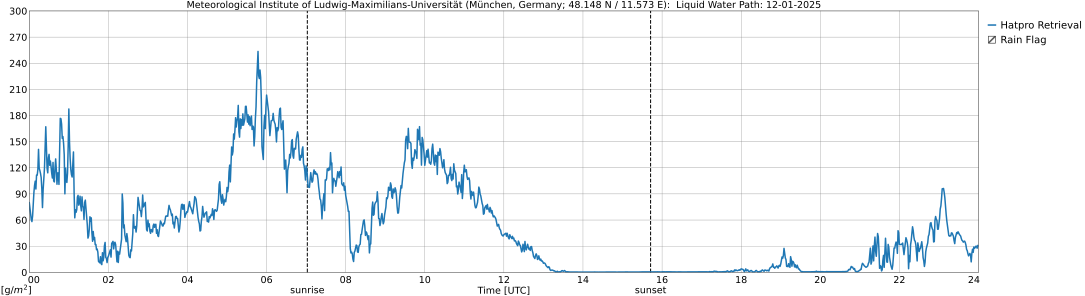

In [40]:
lwp = TimeSeriesPlot(date, 'Liquid Water Path', pre_title=pre_title)
ax = lwp.add_axis(lower_ylabel=True, ylabel='[g/$m^2$]')

ax.plot(pred.time, pred.lwp, label='Hatpro Retrieval (NN)')

ax.set_best_ylim(step_of_step=10, fix_min=0)

rain_flag_mask = pred['rain_flag'] > 0
ax.add_hatches(rain_flag_mask.time.values, rain_flag_mask.values)

lwp.create_legend_with_handles()
lwp.show()

For some standard plots, like the ones above, convenience methods are available in the TimeSeriesCreator class from openMWR.plot. 

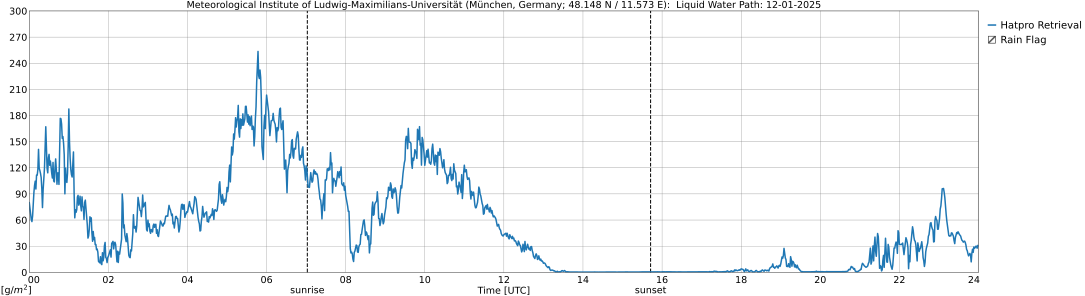

In [41]:
from openMWR.plot import TimeSeriesCreator

temp = TimeSeriesCreator.temp(date, 
                              data, 
                              pre_title=pre_title, 
                              retrieval_label='Hatpro Retrieval (NN)')
temp.show()
lwp = TimeSeriesCreator.lwp(date, 
                            pred, 
                            pre_title=pre_title, 
                            retrieval_label='Hatpro Retrieval (NN)')
lwp.show()

## Boundary Layer Scan Retrieval

Boundary layer scan retrievals can be run and plotted in a similar way. The only difference is that the data is imported using the import_hatpro_data_bls function from openMWR.hatpro_data. Alternatively, the import_data_and_run_retrieval function can be used with the keyword bls=True.

In [42]:
from openMWR.models import Model
model_bls = Model.load('NN_BLS_opt', site, DATA_DIR)

In [43]:
from openMWR.hatpro_data import import_hatpro_data_bls

ds_hatpro_bls = import_hatpro_data_bls(date, 
                                       site, 
                                       import_retrieval_data=False, 
                                       mean_one_min=True)
ds_hatpro_bls

<xarray.Dataset> Size: 45kB
Dimensions:           (time: 72, frq: 14, ang: 10)
Coordinates:
  * time              (time) datetime64[ns] 576B 2025-01-12T00:05:17 ... 2025...
  * frq               (frq) float64 112B 22.24 23.04 23.84 ... 56.66 57.3 58.0
  * ang               (ang) float64 80B 4.2 4.8 5.4 6.6 ... 14.4 19.2 30.0 90.0
Data variables:
    TB                (time, frq, ang) float32 40kB 154.3 145.6 ... 270.0 268.5
    rain_flag         (time) float64 576B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    azimuth_angle     (time) float32 288B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    surface_p         (time) float64 576B 965.0 965.2 965.4 ... 974.2 973.9
    surface_T         (time) float64 576B 270.9 271.0 271.0 ... 271.1 271.1
    surface_rh        (time) float64 576B 75.92 75.97 76.46 ... 74.88 74.2 73.77
    doy_cos           (time) float64 576B 0.9292 0.9292 0.9292 ... 0.9292 0.9292
    doy_sin           (time) float64 576B 0.3695 0.3695 0.3695 ... 0.3695 0.3695
    years_since_1970  (time) float64 576B 55.03 55.03 55.03 ... 55.03 55.03
Attributes:
    netCDF_Convention:             CF-1.0
    Radiometer_Location:           University of Madison
    Radiometer_System:             RPG-HATPRO
    Serial_Number:                 R-DPR-19/007
    Station_Altitude:              200
    Station_Longitude:             85�43'55'' West
    Station_Latitude:              43�22'42'' North
    Comment:                       
    Radiometer_Software_Version:  V10.00
    Host-PC_Software_Version:     V10.00

In [44]:
pred_bls = run_model(model_bls, ds_hatpro_bls, device)
pred_bls

<xarray.Dataset> Size: 346kB
Dimensions:     (time: 72, frq: 14, ang: 10, height: 208)
Coordinates:
  * time        (time) datetime64[ns] 576B 2025-01-12T00:05:17 ... 2025-01-12...
  * frq         (frq) float64 112B 22.24 23.04 23.84 25.44 ... 56.66 57.3 58.0
  * ang         (ang) float64 80B 4.2 4.8 5.4 6.6 8.4 11.4 14.4 19.2 30.0 90.0
  * height      (height) int64 2kB 0 10 25 50 75 ... 28500 29000 29500 30000
Data variables:
    TB          (time, frq, ang) float32 40kB 154.3 145.6 137.0 ... 270.0 268.5
    surface_T   (time) float64 576B 270.9 271.0 271.0 ... 271.1 271.1 271.1
    surface_p   (time) float64 576B 965.0 965.2 965.4 ... 974.3 974.2 973.9
    surface_rh  (time) float64 576B 75.92 75.97 76.46 76.33 ... 74.88 74.2 73.77
    doy_cos     (time) float64 576B 0.9292 0.9292 0.9292 ... 0.9292 0.9292
    doy_sin     (time) float64 576B 0.3695 0.3695 0.3695 ... 0.3695 0.3695
    T           (height, time) float64 120kB 271.4 270.9 271.3 ... 215.2 215.6
    rh          (height, time) float64 120kB 76.07 76.16 76.84 ... 1.09 1.094
    lwc         (height, time) float32 60kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    lwp         (time) float32 288B 91.93 107.7 137.4 ... 118.4 96.54 87.84
    iwv         (time) float64 576B 6.692 7.291 7.162 ... 4.296 4.356 4.202
Attributes:
    netCDF_Convention:             CF-1.0
    Radiometer_Location:           University of Madison
    Radiometer_System:             RPG-HATPRO
    Serial_Number:                 R-DPR-19/007
    Station_Altitude:              200
    Station_Longitude:             85�43'55'' West
    Station_Latitude:              43�22'42'' North
    Comment:                       
    Radiometer_Software_Version:  V10.00
    Host-PC_Software_Version:     V10.00

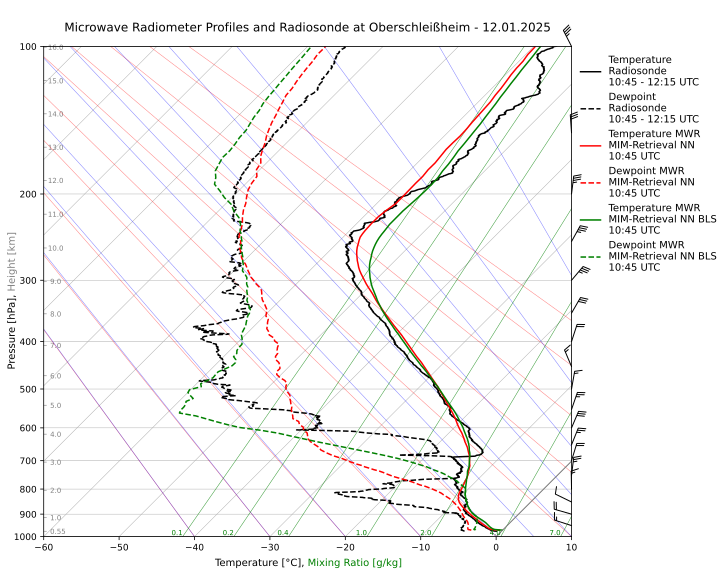

In [47]:
pred_bls = calc_derived_quantities(pred_bls)

skew = SkewT(noon, DATA_DIR, station_alt=station_alt)
skew.plot_radiosonde(raso_station_id)
skew.plot_retrieval(pred, 'MIM-Retrieval NN', color='red')
skew.plot_retrieval(pred_bls, 'MIM-Retrieval NN BLS', color='green')
skew.finalize()